#### Phase 1: Skeleton Extraction and Spatio-Temporal Alignment (Digitization)   
**2D Pose Estimation:** Use RTMPose to extract the 2D skeletal keypoints of dancers from the video (30 frames per second).   
**3D Lifting:** Use MotionBERT (or VideoPose3D) to convert the 2D skeleton into 3D coordinates (X, Y, Z), completely eliminating perspective distortion caused by varying camera angles (frontal/side views) across videos from different eras.  
**Coordinate System Normalization:** Relocate the coordinate origin of each frame to the dancer’s pelvis and scale it by torso length to eliminate differences in the dancers’ positions on stage and variations in height.

#### Phase 2: Unsupervised Temporal Segmentation (Kinematic Segmentation)
The system cannot directly cluster a one-hour-long video; it must first be segmented into “individual movements”. Since we do not know what specific movements these are, we can automatically segment them using kinematic boundaries:  
**Calculate Motion Energy:** Track the sum of the movement velocities of full-body keypoints in 3D space.
**Identifying “Static Points” for Segmentation:** Ballet movements typically occur between two stable poses (the initial and final positions). When “motion energy” reaches a local minimum (i.e., the moment when the dancer’s movement is slowest and most stable), a cut is made at that point.   
Output: Tens of thousands of “ballet action clips” of varying lengths.

#### Phase 3: Action Feature Embedding   
This is the most critical step: how do we enable a computer to compare whether two action clips of different lengths are similar?   
**Handcrafted Feature Engineering:** Calculate pure physical metrics from skeleton points.  
**Spatio-Temporal Graph Convolutional Autoencoder (ST-GCN Autoencoder):** Each “action clip” is fed into a deep learning network. The network does not perform classification; its sole responsibility is to compress this complex skeleton sequence into a fixed-length mathematical vector (e.g., a 256-dimensional feature vector).   
**Dynamic Time Warping (DTW) (Traditional Alternative):** Without using deep learning, the physical similarity distance between two skeleton sequences can be calculated directly using the DTW algorithm.   

#### Phase 4: Dimension Reduction and Clustering Discovery   
Now, tens of thousands of action clips have been transformed into tens of thousands of vector points.
Dimension Reduction and Visualization (UMAP or t-SNE): Reduce the 256-dimensional features to a 2D plane for display. Similar actions automatically cluster together to form “galaxies.”
Density-Based Clustering (HDBSCAN): Run an automatic clustering algorithm. It automatically identifies which actions belong to major categories (such as various jumps) and which are rare, isolated actions (outliers or extremely specific variants).   
K-Means: Euclidean distance.
Agglomerative: Cosine similarity.  
Output: The system tells: “I have identified 50 clusters. Cluster 1 contains 400 similar movements, Cluster 2 contains 150 similar movements…”

#### Phase 5: Human-in-the-Loop Screening and Evaluation      
Expert Annotation and Screening: We (the researchers) open the video samples for “Cluster 1” and find that they are all “Grand Jeté,” so we name Cluster 1 “Grand Jeté”; we open “Cluster 2” and find that they are all “Pirouette”, so we name it “Pirouette”. Directly exclude irrelevant clusters (such as walking or bowing).   
Directed Quantitative Analysis: Once a cluster has been confirmed as a “Grand Jeté”, apply the physical measurement formulas or use the feature vectors to complete the chronological comparison of stylistic evolution.   

In [26]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import cv2
import librosa
from scipy.signal import find_peaks
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from moviepy.editor import VideoFileClip
from mmpose.apis import MMPoseInferencer
import json
import csv
import pickle

# ---------------------------------------------------------
# Module 1: Audio Anchor
# ---------------------------------------------------------
class AudioSynchronizer:
    def __init__(self, threshold_percentile=80):
        """
        Initialize the AudioSynchronizer.
        :param threshold_percentile: The percentile used to calculate the adaptive threshold for music onset.
        """
        self.threshold = threshold_percentile

    def extract_audio_array(self, video_path):
        """
        Extracts the audio track from a video and loads it as a numpy array.
        This prevents repeated I/O operations by extracting the audio only once.
        """
        print(f"   🎧 Extracting Audio Track for Analysis: {os.path.basename(video_path)}")
        temp_audio_path = f"temp_audio_{os.path.basename(video_path)}.wav"
        
        try:
            video_clip = VideoFileClip(video_path)
            if video_clip.audio is None:
                print("      ⚠️ No audio track found. Defaulting to full duration.")
                video_clip.close()
                return None, None, video_clip.duration
                
            # Export temporarily to WAV for librosa compatibility
            video_clip.audio.write_audiofile(temp_audio_path, logger=None)
            total_duration = video_clip.duration
            video_clip.close()
            
            # Load with librosa at 16kHz for faster processing
            y, sr = librosa.load(temp_audio_path, sr=22050)
            
            # Burn after reading: clean up temporary file
            if os.path.exists(temp_audio_path):
                os.remove(temp_audio_path)
                
            return y, sr, total_duration
            
        except Exception as e:
            print(f"      ❌ Audio extraction failed: {e}")
            if os.path.exists(temp_audio_path):
                os.remove(temp_audio_path)
            return None, None, None

    def find_music_start_time(self, y, sr):
        """
        Extracts audio from the video and automatically locates the true starting point
        of the accompaniment music using RMS energy analysis.

        :return: Music start time in seconds (float).
        """
        # print(f"[Module 1] 🎵 Extracting audio track from {os.path.basename(video_path)}...")

        try:
            # video_clip = VideoFileClip(video_path)

            # # If no audio track exists, return 0.0 immediately
            # if video_clip.audio is None:
            #     print("   ⚠️ No audio track found. Defaulting to 0.0s.")
            #     return 0.0
            
            # temp_audio_path = f"temp_audio_{os.path.basename(video_path)}.wav"

            # # Temporarily export the audio track as a wav file for librosa to process
            # video_clip.audio.write_audiofile(temp_audio_path, logger=None)

            # print("[Module 1] 🎵 Analyzing audio features...")
            # # Load audio using librosa. sr=22050 is a standard sampling rate for general analysis
            # y, sr = librosa.load(temp_audio_path, sr=22050)

            if y is None: return 0.0

            # 1. Calculate Root Mean Square (RMS) energy.
            # A frame_length of 2048 corresponds to roughly 0.1 seconds of audio.
            rms = librosa.feature.rms(y=y, frame_length=2048, hop_length=512)[0]
            frames_to_time = librosa.frames_to_time(np.arange(len(rms)), sr=sr, hop_length=512)

            # 2. Set an adaptive threshold based on the global audio energy distribution.
            # Using the 80th percentile acts as a robust criterion for sustained loud sounds (music).
            adaptive_threshold = np.percentile(rms, self.threshold)

            music_start_time = 0.0

            # 3. Search for the onset of "sustained high energy"
            # This logic filters out brief spikes like applause, coughs, or footsteps.
            for i, energy in enumerate(rms):
                if energy > adaptive_threshold:
                    # Look ahead for approximately 3 seconds (about 130 audio frames at hop_length=512)
                    future_window = rms[i:i+130]

                    # If the average energy of the upcoming 3 seconds is also high,
                    # it confirms this is continuous music, not a fleeting noise artifact.
                    if np.mean(future_window) > adaptive_threshold * 0.7:
                        music_start_time = frames_to_time[i]
                        break

        except Exception as e:
            print(f"[Module 1] ⚠️ Error processing audio: {e}")
            music_start_time = 0.0 # Fallback to 0 if audio extraction fails

        # finally:
        #     # Clean up the temporary audio file to free up storage
        #     if os.path.exists(temp_audio_path):
        #         os.remove(temp_audio_path)

        print(f" 🎵 Successfully locked music onset at: {music_start_time:.2f} seconds")
        return music_start_time

    def find_music_end_time(self, y, sr, total_duration, buffer_sec=2.0):
        """
        Precisely trims curtain call applause and ignores mid-performance pauses 
        using joint RMS (Energy) and ZCR (Zero-Crossing Rate) detection.
        """
        if y is None: return total_duration

        hop_length = 512
        rms = librosa.feature.rms(y=y, frame_length=2048, hop_length=hop_length)[0]
        zcr = librosa.feature.zero_crossing_rate(y=y, frame_length=2048, hop_length=hop_length)[0]

        # Normalize features to [0, 1] for thresholding
        rms_norm = rms / (np.max(rms) + 1e-8)
        zcr_norm = zcr / (np.max(zcr) + 1e-8)

        # Smooth signals to prevent micro-jitter misjudgments (1-second window)
        window_size = sr // hop_length 
        rms_smooth = np.convolve(rms_norm, np.ones(window_size)/window_size, mode='same')
        zcr_smooth = np.convolve(zcr_norm, np.ones(window_size)/window_size, mode='same')

        # Dynamically calculate applause ZCR threshold
        zcr_threshold = np.mean(zcr_smooth) + 0.5 * np.std(zcr_smooth)
        
        # Condition: Volume must not be pure silence AND ZCR must be low (excludes applause)
        music_mask = (rms_smooth > 0.05) & (zcr_smooth < zcr_threshold)

        valid_indices = np.where(music_mask)[0]
        times = librosa.frames_to_time(np.arange(len(rms)), sr=sr, hop_length=hop_length)

        if len(valid_indices) > 0:
            last_music_idx = valid_indices[-1]
            last_music_time = times[last_music_idx]
            
            # Add a buffer to preserve the reverb/decay of the final note
            end_time = min(last_music_time + buffer_sec, total_duration)
            print(f" 🎵 Detected End of Music: {end_time:.2f}s (Total: {total_duration:.2f}s)")
            return end_time
        else:
            print(" ⚠️ Could not confidently detect music end. Using full duration.")
            return total_duration

# ---------------------------------------------------------
# Module 2: Spatial Normalizer
# ---------------------------------------------------------
class SpatialNormalizer:
    def __init__(self):
        """
        Initializes the Spatial Normalizer for 3D skeleton sequences.
        Designed for Human3.6M topology (17 joints).
        """
        pass

    def normalize_sequence(self, skeletons_3d):
        """
        Executes full 3D spatial normalization to eliminate global translation, 
        scale variances, and viewpoint discrepancies. Extracts scale-invariant height.
        
        Args:
            skeletons_3d (np.ndarray): Raw 3D coordinates. Shape: (T, 17, 3).
            
        Returns:
            tuple: 
                - skels_for_energy (np.ndarray): Aligned skeletons keeping rotation (for energy calculation).
                - skels_for_clustering (np.ndarray): Fully aligned skeletons (for clustering).
        """
        print("   📐 Executing Full Spatial Normalization (Root -> Scale -> Viewpoint)...")
        
        T, num_joints, dims = skeletons_3d.shape

        skels_for_energy = np.zeros_like(skeletons_3d)
        skels_for_clustering = np.zeros_like(skeletons_3d)
        # relative_heights = np.zeros(T)

        # pelvis_y_array = np.zeros(T)
        # spine_lengths = np.zeros(T)

        # Determine gravity axis
        median_skel = np.median(skeletons_3d, axis=0)
        v_spine_median = median_skel[8] - median_skel[0] 
        
        vertical_axis_idx = np.argmax(np.abs(v_spine_median))
        
        horizontal_indices = [i for i in range(3) if i != vertical_axis_idx]
        h1, h2 = horizontal_indices[0], horizontal_indices[1]
        
        for t in range(T):
            frame_3d = skeletons_3d[t].copy()
            
            # 1. Root Alignment (Translation Invariance)
            # Joint 0 is the Pelvis (Root). We subtract its coordinates from 
            # all joints to center the dancer at the origin (0, 0, 0).
            pelvis_3d = frame_3d[0].copy()
            frame_3d = frame_3d - pelvis_3d
            
            # 2. Scale Normalization (Scale Invariance)
            # Joint 8 is the Neck. We use the Euclidean distance between the 
            # Pelvis and the Neck as the absolute spine length.
            neck_3d = frame_3d[8]
            spine_length_3d = np.linalg.norm(neck_3d - frame_3d[0]) 
            
            if spine_length_3d > 1e-5: # Prevent division by zero
                # Divide all coordinates by spine length. The dancer's proportions 
                # are now standardized, neutralizing camera zoom and actor height.
                frame_3d = frame_3d / spine_length_3d
                
            skels_for_energy[t] = frame_3d.copy()
            
            # 3. Viewpoint Normalization (Rotation Invariance)
            # Joint 11 is Left Shoulder, Joint 14 is Right Shoulder.
            # We project the shoulder vector onto the horizontal plane (ground).
            l_shoulder = frame_3d[11]
            r_shoulder = frame_3d[14]
            dy = l_shoulder[h2] - r_shoulder[h2]
            dx = l_shoulder[h1] - r_shoulder[h1]
            theta = np.arctan2(dy, dx)
            
            # Construct a Y-axis rotation matrix to counter-rotate the body, 
            # forcing the dancer to face the camera dead-on (parallel to X-axis).
            cos_t = np.cos(-theta)
            sin_t = np.sin(-theta)
            R = np.eye(3)
            R[h1, h1] = cos_t
            R[h1, h2] = -sin_t
            R[h2, h1] = sin_t
            R[h2, h2] = cos_t
            
            # Apply orthogonal projection matrix
            skels_for_clustering[t] = np.dot(frame_3d, R.T)

            # frame_2d = skeletons_2d[t]
            # pelvis_2d = frame_2d[0] # [X, Y]
            # neck_2d = frame_2d[8]   # [X, Y]
            
            # pelvis_y_array[t] = pelvis_2d[1]
            # spine_lengths[t] = np.linalg.norm(neck_2d - pelvis_2d)
            
            # if spine_length_2d > 1e-5:
            #     relative_heights[t] = pelvis_2d[1] / spine_length_2d
            
        return skels_for_energy, skels_for_clustering
    
# ==========================================
# Module 3: Kinematic Segmentation
# ==========================================
class KinematicSegmenter:
    def __init__(self, fps, min_duration_sec=0.8, debounce_sec=0.8, activity_thresh=0.05, min_bounce_thresh=0.01):
        """
        Initializes the Advanced Kinematic Segmenter.
        Args:
            fps: Video frames per second.
            min_duration_sec: Minimum duration for a valid action step.
            activity_thresh: The minimum Peak-to-Base ratio to confirm activity.
            min_bounce_thresh: The absolute minimum bounce required from the SMALLER peak (e.g., 0.01 = 1% of global fluctuation).
                               Prevents "staircase effect" false valleys.
        """
        self.fps = fps
        self.min_frames = int(min_duration_sec * fps)
        self.debounce_frames = int(debounce_sec * fps)
        self.activity_thresh = activity_thresh
        self.min_bounce_thresh = min_bounce_thresh

    def segment(self, skeletons_3d):
        T = len(skeletons_3d)

        print("[Segmenter] 📊 Calculating kinematic energy...")
        e_3d = np.zeros(T)
        for i in range(1, T):
            diff = skeletons_3d[i] - skeletons_3d[i-1]
            e_3d[i] = np.sum(np.linalg.norm(diff, axis=1))

        # e_vertical = np.zeros(T)
        # for i in range(1, T):
        #     e_vertical[i] = abs(relative_heights[i] - relative_heights[i-1])

        # if np.max(e_3d) > 0: 
        #     e_3d = e_3d / np.max(e_3d)
        # if np.max(e_vertical) > 0: 
        #     e_vertical = e_vertical / np.max(e_vertical)

        # fused_energy = e_3d + (1.1 * e_vertical)

        # Smooth the energy curve
        window = int(self.fps * 0.5)
        energy = np.convolve(e_3d, np.ones(window)/window, mode='same')

        # Global statistics for activity filtering later
        global_mean_energy = np.mean(energy)
        global_std_energy = np.std(energy)

        inverted_energy = -energy
        
        # energy_range = np.max(energy) - np.min(energy)
        # dynamic_prominence = energy_range * 0.1
        
        peaks, _ = find_peaks(inverted_energy)

        all_valleys = [0] + list(peaks) + [T - 1]

        valid_valleys = []
        valley_drops = {} 
        
        threshold = (np.max(energy) - np.min(energy)) * 0.05

        required_minimum_bounce = (np.max(energy) - np.min(energy)) * self.min_bounce_thresh

        valid_valleys.append(0)
        valley_drops[0] = float('inf') 
        
        for i in range(1, len(all_valleys) - 1):
            v = all_valleys[i]
            v_prev = all_valleys[i-1]
            v_next = all_valleys[i+1]
            
            # Find the highest peaks in the left and right adjacent regions
            p_left_max = np.max(energy[v_prev : v+1])
            p_right_max = np.max(energy[v : v_next+1])
            
            max_adjacent_peak = max(p_left_max, p_right_max)
            drop = max_adjacent_peak - energy[v]

            min_adjacent_peak = min(p_left_max, p_right_max)
            minimum_bounce = min_adjacent_peak - energy[v]
            
            if drop > threshold:
                valid_valleys.append(v)
                valley_drops[v] = drop
                
        valid_valleys.append(T - 1)
        valley_drops[T - 1] = float('inf')

        # Enforce Minimum Duration constraints
        while True:
            too_close = False
            for i in range(1, len(valid_valleys)):
                if valid_valleys[i] - valid_valleys[i-1] < self.min_frames:
                    too_close = True
                    
                    if valid_valleys[i-1] == 0:
                        remove_idx = i
                    elif valid_valleys[i] == T - 1:
                        remove_idx = i - 1
                    else:
                        drop_left = valley_drops[valid_valleys[i-1]]
                        drop_right = valley_drops[valid_valleys[i]]
                        remove_idx = i if drop_right < drop_left else i - 1
                        
                    valid_valleys.pop(remove_idx)
                    break # Recheck
            
            if not too_close:
                break
        
        clips = []
        # for i in range(len(valid_valleys) - 1):
        #     start = valid_valleys[i]
        #     end = valid_valleys[i+1]
        #     if (end - start) >= self.min_frames:
        #         clips.append((start, end))
        for i in range(len(valid_valleys) - 1):
            clips.append((valid_valleys[i], valid_valleys[i+1]))

        # Static Pose Filtering
        active_clips = []
        for start, end in clips:
            seg_energy = energy[start:end]
            if len(seg_energy) < 5: 
                continue 
                
            seg_ptb = np.max(seg_energy) - np.min(seg_energy)
            seg_std = np.std(seg_energy)
            
            is_active_ptb = seg_ptb > (global_mean_energy * self.activity_thresh)
            is_active_std = seg_std > (global_std_energy * self.activity_thresh)
            
            if is_active_ptb and is_active_std:
                active_clips.append((start, end))
        
        debug_data = {
            'e_3d': e_3d,
            'smoothed_energy':energy,
            'clips': active_clips
        }
                
        print(f"[Segmenter] ✂️ Found {len(active_clips)} valid action clips.")
        return active_clips, debug_data

# ==========================================
# Module 4: Feature Encoding
# ==========================================
class BalletFeatureExtractor:
    def __init__(self):
        """
        Initializes the Ballet Feature Extractor.
        Calculates handcrafted biomechanical features based on Vaganova methodology.
        Assumes Human3.6M 17-joint topology.
        """
        # Joint Indices for Human3.6M
        self.PELVIS = 0
        self.R_HIP, self.R_KNEE, self.R_ANKLE = 1, 2, 3
        self.L_HIP, self.L_KNEE, self.L_ANKLE = 4, 5, 6
        self.SPINE, self.NECK, self.HEAD = 7, 8, 9
        self.L_SHOULDER, self.L_ELBOW, self.L_WRIST = 11, 12, 13
        self.R_SHOULDER, self.R_ELBOW, self.R_WRIST = 14, 15, 16

    def _angle_between(self, v1, v2):
        """Calculates the angle (in degrees) between two 3D vectors."""
        v1_u = v1 / (np.linalg.norm(v1) + 1e-8)
        v2_u = v2 / (np.linalg.norm(v2) + 1e-8)
        # Clip to [-1.0, 1.0] to prevent arccos NaN due to floating point errors
        dot_product = np.clip(np.dot(v1_u, v2_u), -1.0, 1.0)
        return np.degrees(np.arccos(dot_product))

    def extract_clip_features(self, clip_skels_norm, clip_skels_energy):
        """
        Extracts a 1D feature vector for a single video clip using Temporal Pooling.
        
        Args:
            clip_skels_norm: (T, 17, 3) - Fully normalized (used for angles).
            clip_skels_energy: (T, 17, 3) - Retains viewpoint (used for rotation).
        """
        T = len(clip_skels_norm)
        if T == 0:
            return np.zeros(0) # Failsafe

        # Initialize temporal arrays for all features
        f_knees = np.zeros((T, 2))      # [Left, Right]
        f_elbows = np.zeros((T, 2))     # [Left, Right]
        f_shoulders = np.zeros((T, 2))  # [Left, Right]
        f_trunk_align = np.zeros(T)
        f_leg_span = np.zeros(T)
        f_verticality = np.zeros((T, 4)) # [L_Arm, R_Arm, L_Leg, R_Leg] Y-offset
        f_symmetry = np.zeros((T, 2))    # [Knee Diff, Elbow Diff]
        f_angular_vel = np.zeros(T)

        prev_theta = None

        # Gravity Axis Detection
        median_skel = np.median(clip_skels_norm, axis=0)
        v_spine_median = median_skel[self.NECK] - median_skel[self.PELVIS]
        vertical_axis_idx = np.argmax(np.abs(v_spine_median))
        
        gravity_vector = np.zeros(3)
        gravity_vector[vertical_axis_idx] = np.sign(v_spine_median[vertical_axis_idx])

        for t in range(T):
            # 1. Use the fully normalized skeleton for internal geometry
            skel = clip_skels_norm[t]
            
            # Vectors definition
            v_l_thigh = skel[self.L_HIP] - skel[self.L_KNEE]
            v_l_calf = skel[self.L_ANKLE] - skel[self.L_KNEE]
            v_r_thigh = skel[self.R_HIP] - skel[self.R_KNEE]
            v_r_calf = skel[self.R_ANKLE] - skel[self.R_KNEE]
            
            v_l_bicep = skel[self.L_SHOULDER] - skel[self.L_ELBOW]
            v_l_forearm = skel[self.L_WRIST] - skel[self.L_ELBOW]
            v_r_bicep = skel[self.R_SHOULDER] - skel[self.R_ELBOW]
            v_r_forearm = skel[self.R_WRIST] - skel[self.R_ELBOW]
            
            v_spine_up = skel[self.NECK] - skel[self.PELVIS]
            v_spine_down = skel[self.PELVIS] - skel[self.NECK]
            v_l_arm = skel[self.L_ELBOW] - skel[self.L_SHOULDER]
            v_r_arm = skel[self.R_ELBOW] - skel[self.R_SHOULDER]

            # --- Feature 1: Joint Angles (Knees, Elbows, Shoulders) ---
            l_knee_ang = self._angle_between(v_l_thigh, v_l_calf)
            r_knee_ang = self._angle_between(v_r_thigh, v_r_calf)
            f_knees[t] = [l_knee_ang, r_knee_ang]
            
            l_elbow_ang = self._angle_between(v_l_bicep, v_l_forearm)
            r_elbow_ang = self._angle_between(v_r_bicep, v_r_forearm)
            f_elbows[t] = [l_elbow_ang, r_elbow_ang]

            l_shoulder_ang = self._angle_between(v_spine_down, v_l_arm)
            r_shoulder_ang = self._angle_between(v_spine_down, v_r_arm)
            f_shoulders[t] = [l_shoulder_ang, r_shoulder_ang]

            # --- Feature 2: Trunk Alignment (Verticality of Spine) ---
            # Angle between Spine and Gravity Vector
            f_trunk_align[t] = self._angle_between(v_spine_up, gravity_vector)

            # --- Feature 3: Leg Extension Angles (Grand Jeté Span) ---
            # Angle between Left Ankle-Hip vector and Right Ankle-Hip vector
            v_l_leg_full = skel[self.L_ANKLE] - skel[self.L_HIP]
            v_r_leg_full = skel[self.R_ANKLE] - skel[self.R_HIP]
            f_leg_span[t] = self._angle_between(v_l_leg_full, v_r_leg_full)

            # --- Feature 4: Limb Positioning Relative to Vertical ---
            f_verticality[t] = [
                skel[self.L_WRIST][vertical_axis_idx] - skel[self.PELVIS][vertical_axis_idx],
                skel[self.R_WRIST][vertical_axis_idx] - skel[self.PELVIS][vertical_axis_idx],
                skel[self.L_ANKLE][vertical_axis_idx] - skel[self.PELVIS][vertical_axis_idx],
                skel[self.R_ANKLE][vertical_axis_idx] - skel[self.PELVIS][vertical_axis_idx]
            ]

            # --- Feature 5: Bilateral Limb Symmetry ---
            f_symmetry[t] = [
                abs(l_knee_ang - r_knee_ang),
                abs(l_elbow_ang - r_elbow_ang)
            ]

            # --- Feature 6: Rotational Angular Velocity (Using Unrotated Skeleton) ---
            # We must use clip_skels_energy to measure how fast the body is spinning
            horizontal_indices = [i for i in range(3) if i != vertical_axis_idx]
            skel_raw = clip_skels_energy[t]
            l_sh_raw = skel_raw[self.L_SHOULDER]
            r_sh_raw = skel_raw[self.R_SHOULDER]
            shoulder_vec_raw = l_sh_raw - r_sh_raw
            
            # Project to horizontal plane and calculate angle
            current_theta = np.arctan2(shoulder_vec_raw[horizontal_indices[1]], shoulder_vec_raw[horizontal_indices[0]])
            
            if prev_theta is not None:
                # Shortest path angular difference (handles -pi to pi wrap around)
                angle_diff = (current_theta - prev_theta + np.pi) % (2 * np.pi) - np.pi
                # Convert to degrees per frame
                f_angular_vel[t] = abs(np.degrees(angle_diff))
            else:
                f_angular_vel[t] = 0.0
                
            prev_theta = current_theta

        # ==========================================
        # TEMPORAL STATISTICAL POOLING (Compression)
        # ==========================================
        # Compress the time dimension (T) into Max, Min, Mean, and Variance
        pooled_features = []

        def pool_array(arr):
            # arr shape: (T,) or (T, D)
            if len(arr.shape) == 1:
                return [np.max(arr), np.min(arr), np.mean(arr), np.std(arr)]
            else:
                res = []
                for d in range(arr.shape[1]):
                    res.extend([np.max(arr[:, d]), np.min(arr[:, d]), np.mean(arr[:, d]), np.std(arr[:, d])])
                return res

        pooled_features.extend(pool_array(f_knees))         # 8 dims
        pooled_features.extend(pool_array(f_elbows))        # 8 dims
        pooled_features.extend(pool_array(f_shoulders))     # 8 dims
        pooled_features.extend(pool_array(f_trunk_align))   # 4 dims
        pooled_features.extend(pool_array(f_leg_span))      # 4 dims
        pooled_features.extend(pool_array(f_verticality))   # 16 dims
        pooled_features.extend(pool_array(f_symmetry))      # 8 dims
        pooled_features.extend(pool_array(f_angular_vel))   # 4 dims
        
        # Add the 2D Relative Height features
        # pooled_features.extend(pool_array(clip_rel_heights)) # 4 dims

        return np.array(pooled_features) # Total: 60 highly interpretive dimensions!

    def extract_dataset(self, clips, skels_for_energy, skels_for_clustering):
        """Processes all segmented clips in a video."""
        all_features = []
        for start, end in clips:
            clip_f = self.extract_clip_features(
                clip_skels_norm = skels_for_clustering[start:end],
                clip_skels_energy = skels_for_energy[start:end]
            )
            all_features.append(clip_f)
        return np.array(all_features)
    
# ==========================================
# Module 5: Clustering
# ==========================================
class ActionClusterEngine:
    def __init__(self, target_frames=90):
        # Normalize all clips to 3 seconds (90 frames) for consistent vector lengths
        self.target_frames = target_frames 
        
    def extract_features(self, skeletons_3d, clips):
        print("[Clustering] 🧠 Extracting and normalizing features...")
        features = []
        
        for start, end in clips:
            clip_data = skeletons_3d[start:end] # Shape: (T, 17, 3)
            
            # Temporal Interpolation (Resampling to exactly 90 frames)
            # This is crucial so every action can be compared mathematically
            indices = np.linspace(0, len(clip_data) - 1, self.target_frames)
            resampled_clip = np.zeros((self.target_frames, 17, 3))
            
            for j in range(17):
                for k in range(3):
                    resampled_clip[:, j, k] = np.interp(indices, np.arange(len(clip_data)), clip_data[:, j, k])
            
            # Flatten the 3D data into a single 1D vector (90 * 17 * 3 = 4590 dimensions)
            flattened_vector = resampled_clip.flatten()
            features.append(flattened_vector)
            
        return np.array(features)

    def cluster_global_auto(self, global_features, max_clusters=50):
        print("[Clustering] 🌌 Performing Clustering...")
        if isinstance(global_features, list):
            feature_matrix = np.vstack(global_features)
        else:
            feature_matrix = global_features
            
        n_samples = len(feature_matrix)
        print(f"\n   📊 Processing 60D Feature Matrix: {n_samples} clips found.")
        
        if n_samples < 3:
            print("   ⚠️ Not enough samples to perform clustering.")
            return np.zeros(n_samples, dtype=int), 1
        
        # 1. Standardize
        scaler = StandardScaler()
        scaled_features = scaler.fit_transform(global_features)
        
        # 2. Feature Boosting
        weighted_features = scaled_features.copy()
        weighted_features[:, -4:] *= 2.0    # angular velocity
        weighted_features[:, 32:36] *= 1.5  # leg span
        
        # 3. K-Means Clustering
        best_k = 10
        best_score = -1.0
        best_labels = None
        
        # Determine upper bound for k (cannot exceed number of samples)
        upper_bound = min(max_clusters, n_samples - 1)
        
        print("\n   [Auto-K Evaluation]")
        for k in range(10, upper_bound + 1):
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = kmeans.fit_predict(weighted_features)
            score = silhouette_score(weighted_features, labels)
            print(f"      k={k} | Silhouette Score: {score:.4f}")
            # clusterer = AgglomerativeClustering(n_clusters=k, metric='cosine', linkage='average')
            # labels = clusterer.fit_predict(weighted_features)
            # score = silhouette_score(weighted_features, labels, metric='cosine')
            # print(f"      k={k:2d} | Cosine Silhouette Score: {score:.4f}")
            
            if score > best_score:
                best_score = score
                best_k = k
                best_labels = labels
                
        print(f"   🏆 Optimal Clusters Selected: {best_k} (Score: {best_score:.4f})")
        return best_labels, best_k


# ==========================================
# Module 6: Visualization
# ==========================================
class BalletVisualizer:
    def __init__(self):
        """
        Initializes the visualization engine for ballet kinematics and 3D features.
        """
        # Human3.6M skeleton topology
        self.BONES = [
            (0, 1), (1, 2), (2, 3),       # Right Leg
            (0, 4), (4, 5), (5, 6),       # Left Leg
            (0, 7), (7, 8), (8, 9),       # Spine & Head
            (8, 11), (11, 12), (12, 13),  # Left Arm
            (8, 14), (14, 15), (15, 16)   # Right Arm
        ]

    def plot_segmentation_signals(self, debug_data, fps=30):
        """
        Plots the multi-modal energy signals and segmentation boundaries.
        """
        e_3d = debug_data['e_3d']
        smoothed_energy = debug_data['smoothed_energy']
        clips = debug_data['clips']
        
        time_axis = np.arange(len(e_3d)) / fps

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
        fig.suptitle("Kinematic Segmentation & Height Gating Analysis", fontsize=16, fontweight='bold')

        # Subplot 1: Raw Energies
        ax1.plot(time_axis, e_3d, label='3D Shape Energy', color='blue', alpha=0.6)
        ax1.set_ylabel("Raw Energy")
        ax1.legend(loc="upper right")
        ax1.grid(True, linestyle='--', alpha=0.5)

        # Subplot 2: Smoothed Energy & Cut Points
        ax2.plot(time_axis, smoothed_energy, label='Smoothed Energy', color='purple', linewidth=2)
        # Highlight Segmentation Bounds
        for idx, (start, end) in enumerate(clips):
            ax2.axvline(x=start/fps, color='green', linestyle='--', linewidth=1.5)
            ax2.axvline(x=end/fps, color='red', linestyle='--', linewidth=1.5)
            ax2.axvspan(start/fps, end/fps, color='green', alpha=0.1) # Shaded clip region
            ax2.text((start+end)/(2*fps), max(smoothed_energy)*0.9, f"Clip {idx}", ha='center', color='darkgreen')
        ax2.set_ylabel("Smoothed Energy")
        ax2.legend(loc="upper right")
        ax2.grid(True, linestyle='--', alpha=0.5)

        plt.tight_layout()
        plt.show()

    def _calc_angle(self, v1, v2):
        cosine_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-8)
        return np.degrees(np.arccos(np.clip(cosine_angle, -1.0, 1.0)))

    def plot_3d_skeleton_features(self, skeleton_norm, title="3D Biomechanical Features"):
        """
        Plots a single frame 3D skeleton and annotates handcrafted features.
        skeleton_norm: (17, 3) aligned coordinates.
        """
        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(111, projection='3d')
        
        pelvis_raw = skeleton_norm[0]
        neck_raw = skeleton_norm[8]
        v_spine_raw = neck_raw - pelvis_raw

        vertical_axis_idx = np.argmax(np.abs(v_spine_raw))
        horizontal_indices = [i for i in range(3) if i != vertical_axis_idx]

        xs = skeleton_norm[:, horizontal_indices[0]]
        ys = skeleton_norm[:, horizontal_indices[1]]
        
        gravity_sign = np.sign(v_spine_raw[vertical_axis_idx])
        zs = skeleton_norm[:, vertical_axis_idx] * gravity_sign
        # # Extract X, Y, Z (Note: in matplotlib 3D, Z is up. If Y is up in your data, swap them)
        # xs = skeleton_norm[:, 0]
        # ys = skeleton_norm[:, 2] # Swapping Y and Z for better matplotlib viewing
        # zs = -skeleton_norm[:, 1] # Invert original Y to make dancer stand upright
        
        # 1. Draw Bones
        for start_idx, end_idx in self.BONES:
            ax.plot([xs[start_idx], xs[end_idx]], 
                    [ys[start_idx], ys[end_idx]], 
                    [zs[start_idx], zs[end_idx]], 
                    color='black', linewidth=2, marker='o', markersize=4, markerfacecolor='blue')
            
        # 2. Highlight Gravity Vector (Trunk Alignment)
        pelvis = np.array([xs[0], ys[0], zs[0]])
        neck = np.array([xs[8], ys[8], zs[8]])
        # Draw absolute vertical line from pelvis
        ax.plot([pelvis[0], pelvis[0]], [pelvis[1], pelvis[1]], [pelvis[2], pelvis[2] + (neck[2]-pelvis[2])], 
                color='red', linestyle='--', linewidth=1.5, label='Gravity Plumb Line')
        
        # 3. Calculate and annotate specific angles for the plot
        def calc_angle(p1, p2, p3):
            v1 = p1 - p2
            v2 = p3 - p2
            cosine_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-8)
            return np.degrees(np.arccos(np.clip(cosine_angle, -1.0, 1.0)))

        # Left Knee Angle (Hip=4, Knee=5, Ankle=6)
        p_l_hip = np.array([xs[4], ys[4], zs[4]])
        p_l_knee = np.array([xs[5], ys[5], zs[5]])
        p_l_ankle = np.array([xs[6], ys[6], zs[6]])
        l_knee_ang = calc_angle(p_l_hip, p_l_knee, p_l_ankle)
        
        # Annotate Left Knee
        ax.text(p_l_knee[0]+0.05, p_l_knee[1], p_l_knee[2], f"{l_knee_ang:.1f}°", color='red', fontsize=12, fontweight='bold')
        
        # Right Knee Angle (Hip=1, Knee=2, Ankle=3)
        p_r_hip = np.array([xs[1], ys[1], zs[1]])
        p_r_knee = np.array([xs[2], ys[2], zs[2]])
        p_r_ankle = np.array([xs[3], ys[3], zs[3]])
        r_knee_ang = calc_angle(p_r_hip, p_r_knee, p_r_ankle)
        
        # Annotate Right Knee
        ax.text(p_r_knee[0]-0.05, p_r_knee[1], p_r_knee[2], f"{r_knee_ang:.1f}°", color='blue', fontsize=12, fontweight='bold')

        # Trunk Alignment Angle (Neck to Pelvis vs Plumb Line)
        v_spine = neck - pelvis
        v_plumb = np.array([0, 0, 1.0])
        trunk_ang = self._calc_angle(v_spine, v_plumb)
        ax.text(neck[0], neck[1], neck[2]+0.05, f"Trunk Tilt: {trunk_ang:.1f}°", color='darkgreen', fontsize=12)

        # Leg Span
        p_l_hip, p_l_ankle = np.array([xs[4], ys[4], zs[4]]), np.array([xs[6], ys[6], zs[6]])
        p_r_hip, p_r_ankle = np.array([xs[1], ys[1], zs[1]]), np.array([xs[3], ys[3], zs[3]])
        v_l_leg_full = p_l_ankle - p_l_hip
        v_r_leg_full = p_r_ankle - p_r_hip
        leg_span_ang = self._calc_angle(v_l_leg_full, v_r_leg_full)

        hud_text = (
            f"📊 Apex Frame\n"
            f"────────────────────────\n"
            f"Leg Span:  {leg_span_ang:>6.1f}°\n"
            f"Trunk Tilt:{trunk_ang:>6.1f}°\n"
            f"L. Knee:   {l_knee_ang:>6.1f}°\n"
            f"R. Knee:   {r_knee_ang:>6.1f}°\n"
            f"Symmetry:  {abs(l_knee_ang - r_knee_ang):>6.1f}°\n"
        )

        ax.text2D(0.02, 0.98, hud_text, transform=ax.transAxes,
                  fontsize=11, color='black', family='monospace', va='top',
                  bbox=dict(boxstyle='round,pad=0.8', facecolor='white', alpha=0.85, edgecolor='gray'))

        # ax.text(xs[5]+0.05, ys[5], zs[5], f"{l_knee_ang:.0f}°", color='red', fontweight='bold')
        # ax.text(xs[2]-0.05, ys[2], zs[2], f"{r_knee_ang:.0f}°", color='blue', fontweight='bold')

        # Plot Settings
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel(f'Data Axis {horizontal_indices[0]}')
        ax.set_ylabel(f'Data Axis {horizontal_indices[1]}')
        ax.set_zlabel(f'Data Axis {vertical_axis_idx} (Gravity)')
        
        # Force aspect ratio to be equal so the dancer doesn't look squished
        max_range = np.array([xs.max()-xs.min(), ys.max()-ys.min(), zs.max()-zs.min()]).max() / 2.0
        mid_x = (xs.max()+xs.min()) * 0.5
        mid_y = (ys.max()+ys.min()) * 0.5
        mid_z = (zs.max()+zs.min()) * 0.5
        ax.set_xlim(mid_x - max_range, mid_x + max_range)
        ax.set_ylim(mid_y - max_range, mid_y + max_range)
        ax.set_zlim(mid_z - max_range, mid_z + max_range)
        
        ax.legend()
        plt.show()

# ==========================================
# Module 7: Output
# ==========================================
def export_action_clips(clusters, source_folder, output_base_folder):
    """
    Physically extracts video segments and organizes them into folders by Cluster ID.
    """
    print("\n==================================================")
    print(" 🎬 EXPORTING VIDEO CLIPS FOR VERIFICATION ")
    print("==================================================")
    
    for c_id, items in clusters.items():
        # Create a directory for each cluster (e.g., ./ballet_videos/Cluster_0)
        cluster_dir = os.path.join(output_base_folder, f"Cluster_{c_id}")
        if not os.path.exists(cluster_dir):
            os.makedirs(cluster_dir)
            
        print(f"   📂 Processing Cluster {c_id} ({len(items)} clips)...")
        
        # To optimize speed, we group by source video to avoid repeated file opening
        from collections import defaultdict
        video_groups = defaultdict(list)
        for item in items:
            video_groups[item['video']].append(item)
            
        for video_name, segments in video_groups.items():
            video_path = os.path.join(source_folder, video_name)
            if not os.path.exists(video_path):
                print(f"      ⚠️ Source video missing: {video_name}")
                continue
                
            try:
                # Load the original video once per group
                full_video = VideoFileClip(video_path)
                
                for i, seg in enumerate(segments):
                    start_t = seg['start_time']
                    end_t = seg['end_time']
                    
                    # Construct output filename: ClusterID_VideoName_StartTime.mp4
                    clip_filename = f"C{c_id}_{video_name.split('.')[0]}_{start_t:.1f}s.mp4"
                    clip_path = os.path.join(cluster_dir, clip_filename)
                    
                    # Extract and write the subclip
                    # We use a fast preset and remove audio to speed up the process
                    subclip = full_video.subclip(start_t, end_t)
                    subclip.write_videofile(clip_path, codec="libx264", audio=True, logger=None, threads=4)
                    
                full_video.close() # Free resources
            except Exception as e:
                print(f"      ❌ Failed to export clips from {video_name}: {e}")

# ==========================================
# Main Pipeline
# ==========================================
def process_video_folder(folder_path, export_clips=True):
    print("==================================================")
    print("🚀 VIDEO ARCHIVE: BATCH PROCESSING ENGINE STARTED")
    print("==================================================")
    
    video_files = glob.glob(os.path.join(folder_path, "*.mp4"))
    if not video_files:
        print(f"❌ No .mp4 videos found in {folder_path}!")
        return
        
    print(f"📁 Found {len(video_files)} videos for processing.")
    
    # Initialize MMPose Engine ONCE to save VRAM and loading time
    # print("\n🧠 Loading MMPose DL Models into VRAM...")
    # inferencer_2d = MMPoseInferencer(pose2d='human', device='cuda:0')
    # inferencer_3d = MMPoseInferencer(pose2d='human', pose3d='human3d', device='cuda:0')
    
    audio_sync = AudioSynchronizer()
    cluster_engine = ActionClusterEngine()
    
    # Global Data Pool
    global_features = []
    global_metadata = [] 
    
    for idx, video_path in enumerate(video_files):
        vid_name = os.path.basename(video_path)
        
        # Detect dynamic FPS for current video
        cap = cv2.VideoCapture(video_path)
        fps = cap.get(cv2.CAP_PROP_FPS)
        if fps < 1: fps = 30.0 # Fallback for corrupted metadata
        cap.release()
        
        print(f"\n[{idx+1}/{len(video_files)}] Processing Video: {vid_name} (FPS: {fps:.2f})")
        
        # Step 1: Audio Cropping
        y, sr, total_duration = audio_sync.extract_audio_array(video_path)
        music_start_sec = audio_sync.find_music_start_time(y, sr)
        music_end_sec = audio_sync.find_music_end_time(y, sr, total_duration, buffer_sec=1)
        temp_video_path = f"temp_trim_{vid_name}"
        
        try:
            print("   ✂️ Cropping pre-performance noise...")
            clip = VideoFileClip(video_path)
            trimmed_clip = clip.subclip(music_start_sec, music_end_sec)
            trimmed_clip.write_videofile(temp_video_path, codec="libx264", audio=True, logger=None)
            clip.close()
            
            # Step 2: 2D&3D Pose Inference (Bulletproof generator)
            # print("   👁️ Executing Pass 1: Extracting 2D Pixel Coordinates...")
            # all_2d_keypoints = []

            # for result in inferencer_2d(temp_video_path):
            #     preds = result.get('predictions', [])
            #     if len(preds) > 0 and len(preds[0]) > 0:
            #         all_2d_keypoints.append(preds[0][0]['keypoints'])
            #     else:
            #         all_2d_keypoints.append(all_2d_keypoints[-1] if all_2d_keypoints else np.zeros((17, 2)))

            print("   🦴 Extracting 3D Spatial Coordinates...")
            inferencer_3d = MMPoseInferencer(pose3d='human3d', device='cuda:0')
            all_3d_keypoints = []
            frozen_frames_count = 0
       
            for result in inferencer_3d(temp_video_path):
                preds = result.get('predictions', [])
                if len(preds) > 0 and len(preds[0]) > 0:
                    all_3d_keypoints.append(preds[0][0]['keypoints'])
                    frozen_frames_count = 0
                else:
                    all_3d_keypoints.append(all_3d_keypoints[-1] if all_3d_keypoints else np.zeros((17, 3)))
                    frozen_frames_count += 1
                    
                    if frozen_frames_count > 5:
                        print(f"      🚨 WARNING: 3D Model lost tracking for {frozen_frames_count} frames! Producing Zombie Frames!")

            # min_len = min(len(all_2d_keypoints), len(all_3d_keypoints))
            # skeletons_2d = np.array(all_2d_keypoints[:min_len])
            # skeletons_3d = np.array(all_3d_keypoints[:min_len])
            skeletons_3d = np.array(all_3d_keypoints)
            
            print(f"   ✅ Synchronized {len(skeletons_3d)} frames. 3D Shape: {skeletons_3d.shape[1:]}")
            
            if len(skeletons_3d) < 30:
                print("   ⏭️ Video too short after cropping. Skipping.")
                continue
                
            # Step 3: Action Segmentation
            normalizer = SpatialNormalizer()
            skels_for_energy, skels_for_clustering = normalizer.normalize_sequence(skeletons_3d)

            segmenter = KinematicSegmenter(fps=fps, min_duration_sec=0.8)
            clips, debug_data = segmenter.segment(skels_for_energy)
            print(f"   🔪 Found {len(clips)} semantic action clips.")

            visualizer = BalletVisualizer()
            visualizer.plot_segmentation_signals(debug_data, fps=fps)
            
            # Step 4: Extract and Pool Features
            feature_extractor = BalletFeatureExtractor()

            if len(clips) > 0:
                first_clip = clips[0]
                middle_frame_idx = (first_clip[0] + first_clip[1]) // 2 
                
                apex_skeleton = skels_for_clustering[middle_frame_idx]
                
                visualizer.plot_3d_skeleton_features(apex_skeleton, title=f"Apex Frame Features (Frame {middle_frame_idx})")

                features = feature_extractor.extract_dataset(
                    clips, 
                    skels_for_energy, 
                    skels_for_clustering
                )
                global_features.extend(features)
                
                # Restore absolute timestamps mapped to original video
                for start_f, end_f in clips:
                    abs_start = music_start_sec + (start_f / fps)
                    abs_end = music_start_sec + (end_f / fps)
                    global_metadata.append({
                        "video": vid_name,
                        "start_time": abs_start,
                        "end_time": abs_end
                    })
                    
        except Exception as e:
            print(f"   ❌ Fatal error processing {vid_name}: {e}")
            continue
            
        finally:
            # Clean up temporary cropped video to save disk space
            if os.path.exists(temp_video_path):
                os.remove(temp_video_path)
                

    # Step 5: Global Unsupervised Clustering
    if len(global_features) < 3:
        print("\n❌ Not enough total clips extracted from the dataset to perform clustering.")
        return
        
    print("\n🌌 Processing Dataset-Level Global Clustering...")
    labels, optimal_k = cluster_engine.cluster_global_auto(global_features, max_clusters=50)

    # ==========================================
    # Output Dictionary
    # ==========================================
    print("\n==================================================")
    print(" 🎉 GLOBAL ACTION DICTIONARY COMPILED! ")
    print("==================================================")
    
    clusters = {i: [] for i in range(optimal_k)}
    for idx, meta in enumerate(global_metadata):
        c_id = labels[idx]
        clusters[c_id].append(meta)
        
    for c_id, items in clusters.items():
        print(f"\n💠 [MOTIF CLUSTER {c_id}] - Found {len(items)} instances across dataset:")
        for item in items:
            print(f"    ↳ {item['video']} | {item['start_time']:.1f}s - {item['end_time']:.1f}s")
            
    final_dataset = []
    for idx, meta in enumerate(global_metadata):
        data_entry = {
            "video_file": meta['video'],
            "start_time": meta['start_time'],
            "end_time": meta['end_time'],
            "cluster_id": int(labels[idx]),
            "features_60d": global_features[idx] 
        }
        final_dataset.append(data_entry)

    # Output JSON
    json_path = os.path.join(folder_path, "action_dictionary.json")

    serializable_clusters = {str(k): v for k, v in clusters.items()} 
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(serializable_clusters, f, indent=4, ensure_ascii=False)
    print(f"   📄 JSON Exported: {json_path}")

    # Output PKL
    pkl_path = os.path.join(folder_path, "feature_database.pkl")
    with open(pkl_path, 'wb') as f:
        pickle.dump(final_dataset, f)
    print(f"   🧠 Feature Database (Pickle) Exported: {pkl_path}")

    # Output CSV
    csv_path = os.path.join(folder_path, "action_dictionary.csv")
    with open(csv_path, 'w', newline='', encoding='utf-8-sig') as f:
        writer = csv.writer(f)
        
        # Header
        headers = ["Cluster_ID", "Video_File", "Start_Time_sec", "End_Time_sec"]
        headers.extend([f"Feature_{i+1}" for i in range(64)])
        writer.writerow(headers)
        
        for entry in final_dataset:
            row = [
                entry["cluster_id"],
                entry["video_file"],
                round(entry["start_time"], 3),
                round(entry["end_time"], 3)
            ]
  
            feature_list = [round(float(val), 4) for val in entry["features_60d"]]
            row.extend(feature_list)
            
            writer.writerow(row)
            
    print(f"   📊 Enhanced CSV Exported: {csv_path}")

    SOURCE_VIDEOS_FOLDER = "./videos"                        
    OUTPUT_BASE_FOLDER = "./videos/Extracted_Clips"
    export_action_clips(clusters, SOURCE_VIDEOS_FOLDER, OUTPUT_BASE_FOLDER)
    
    print("\n✅ Batch Processing Complete.")

In [4]:
DATASET_FOLDER = "./videos" 
    
if not os.path.exists(DATASET_FOLDER):
    os.makedirs(DATASET_FOLDER)
    print(f"⚠️ Created folder: '{DATASET_FOLDER}'. Insert .mp4 files and run again.")
else:
    process_video_folder(DATASET_FOLDER)

🚀 VIDEO ARCHIVE: BATCH PROCESSING ENGINE STARTED
📁 Found 2 videos for processing.

🧠 Loading MMPose DL Models into VRAM...
Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/rtmpose-m_simcc-body7_pt-body7_420e-256x192-e48f03d0_20230504.pth
Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/rtmdet_m_8xb32-100e_coco-obj365-person-235e8209.pth
Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/v1/body_3d_keypoint/pose_lift/h36m/motionbert_ft_h36m-d80af323_20230531.pth
Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/rtmpose-m_simcc-body7_pt-body7_420e-256x192-e48f03d0_20230504.pth
Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/rtmdet_m_8xb32-100e_coco-obj365-person-235e8209.pth

[1/2] Processing Video: Finalist – Nikhil SENGUPTA, 202 – Prix de 

### Run by module

In [2]:
folder_path = "./videos"

video_files = glob.glob(os.path.join(folder_path, "*.mp4"))

if not video_files:
    print(f"❌ No .mp4 videos found in {folder_path}!")
else:
    print(f"📁 Found {len(video_files)} videos for processing.")

📁 Found 2 videos for processing.


In [27]:
print("\n🧠 Global Initializing...")

audio_sync = AudioSynchronizer()
cluster_engine = ActionClusterEngine()

# Global Data Pool
global_features = []
global_metadata = [] 


🧠 Global Initializing...



[1/2] Processing Video: Finalist – Nikhil SENGUPTA, 202 – Prix de Lausanne 2026 – Classical.mp4 (FPS: 25.00)
   🎧 Extracting Audio Track for Analysis: Finalist – Nikhil SENGUPTA, 202 – Prix de Lausanne 2026 – Classical.mp4
 🎵 Successfully locked music onset at: 16.65 seconds
 🎵 Detected End of Music: 62.72s (Total: 74.42s)
   ✂️ Cropping pre-performance noise...
   🦴 Extracting 3D Spatial Coordinates...
Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/v1/body_3d_keypoint/pose_lift/h36m/motionbert_ft_h36m-d80af323_20230531.pth
Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/rtmpose-m_simcc-body7_pt-body7_420e-256x192-e48f03d0_20230504.pth
Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/rtmdet_m_8xb32-100e_coco-obj365-person-235e8209.pth
   ✅ Synchronized 1152 frames. 3D Shape: (17, 3))
   📐 Executing Full Spatial Normalization (Root -> Scale -

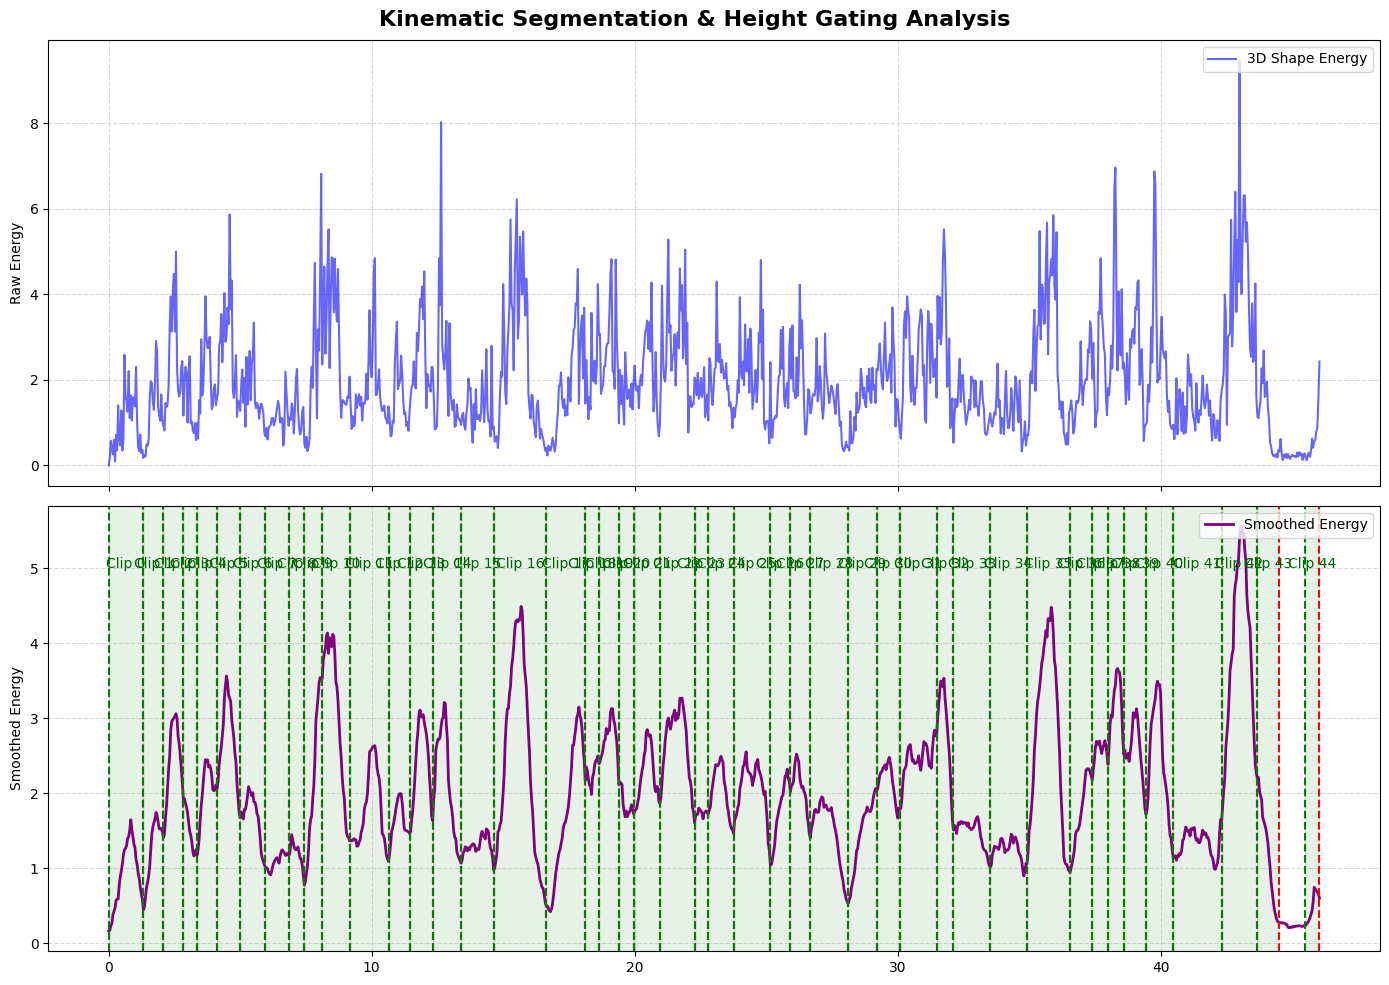

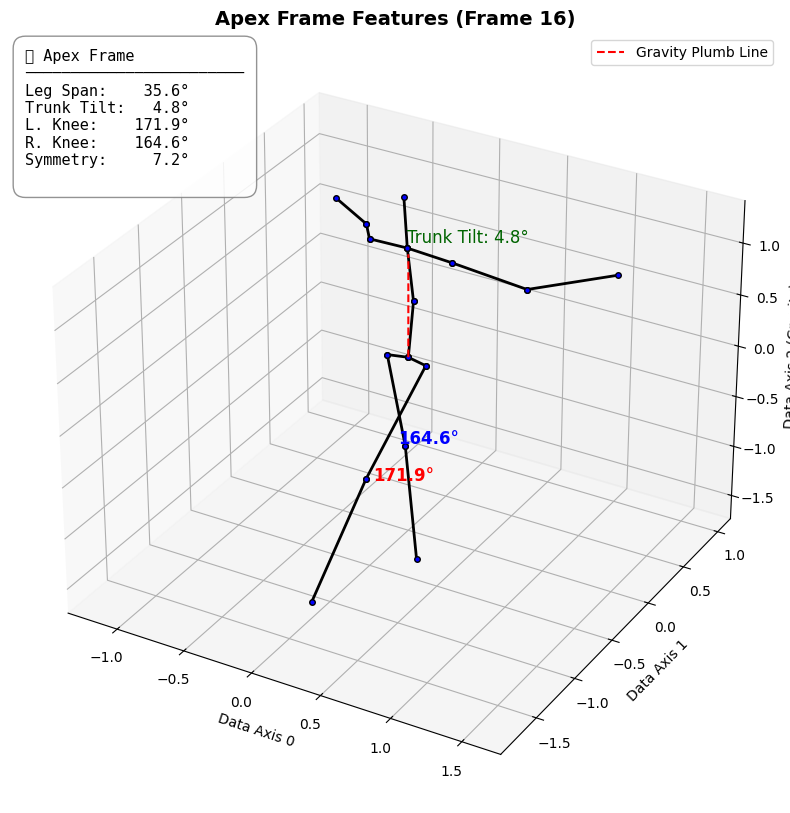


[2/2] Processing Video: Miguel Pinheiro - 2015 Prix de Lausanne Prize Winner - Classical variation.mp4 (FPS: 25.00)
   🎧 Extracting Audio Track for Analysis: Miguel Pinheiro - 2015 Prix de Lausanne Prize Winner - Classical variation.mp4
 🎵 Successfully locked music onset at: 15.51 seconds
 🎵 Detected End of Music: 95.74s (Total: 95.74s)
   ✂️ Cropping pre-performance noise...
   🦴 Extracting 3D Spatial Coordinates...
Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/v1/body_3d_keypoint/pose_lift/h36m/motionbert_ft_h36m-d80af323_20230531.pth
Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/rtmpose-m_simcc-body7_pt-body7_420e-256x192-e48f03d0_20230504.pth
Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/v1/projects/rtmposev1/rtmdet_m_8xb32-100e_coco-obj365-person-235e8209.pth
   ✅ Synchronized 2006 frames. 3D Shape: (17, 3))
   📐 Executing Full Spatial Normalization (R

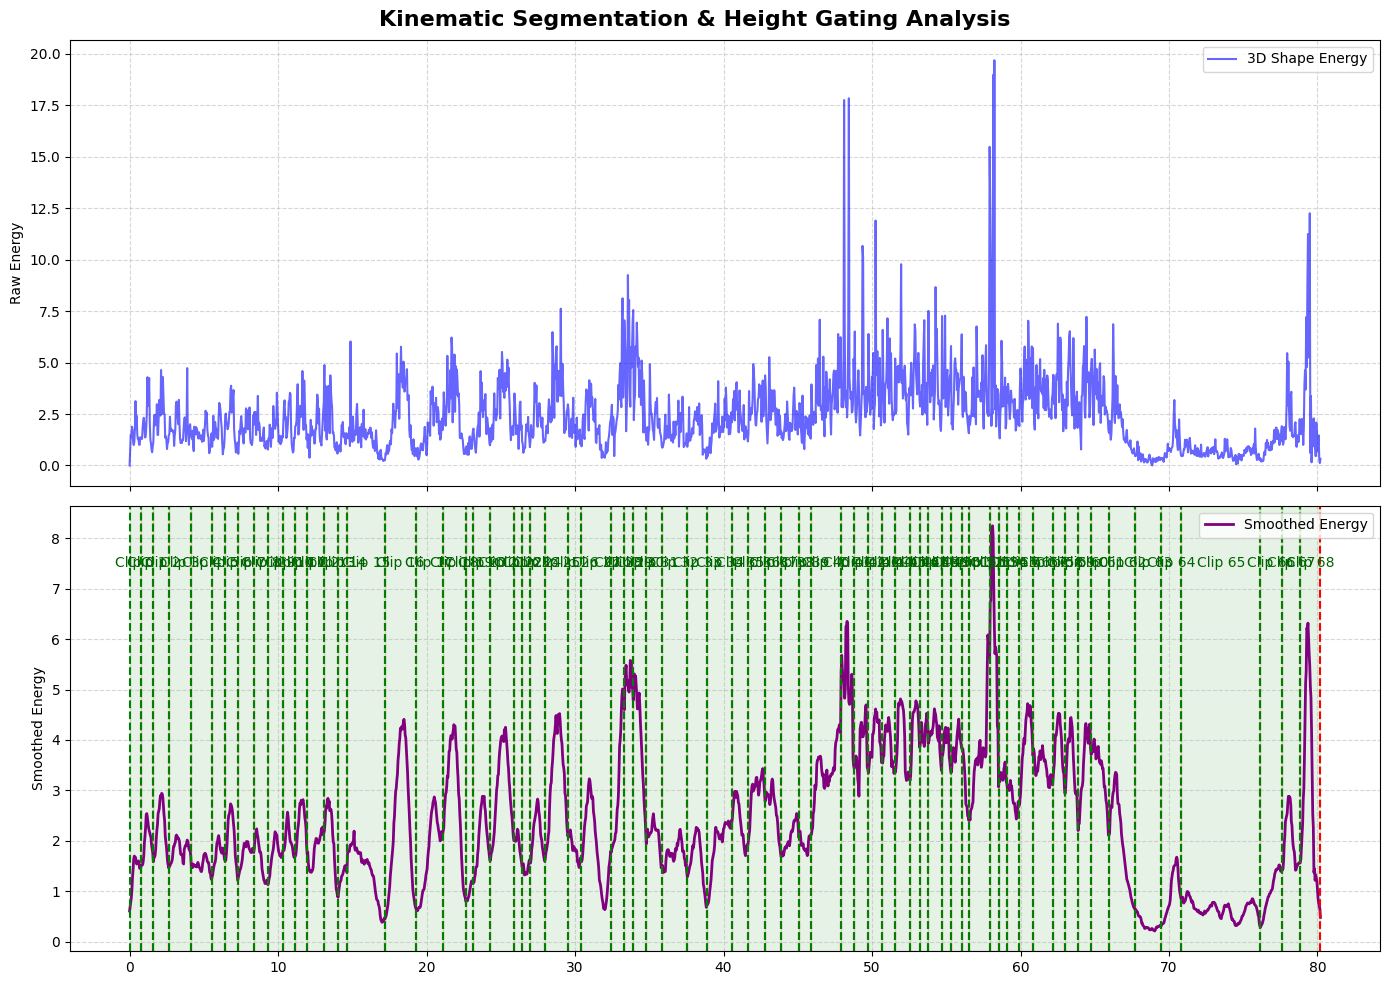

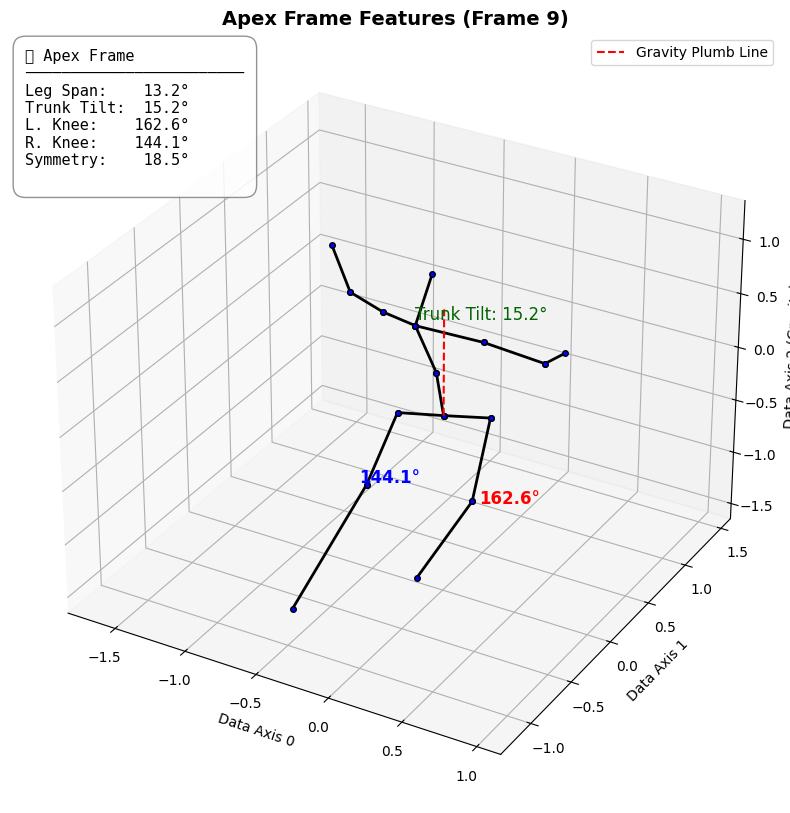

In [28]:
for idx, video_path in enumerate(video_files):
    vid_name = os.path.basename(video_path)
    
    # Detect dynamic FPS for current video
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps < 1: fps = 30.0 # Fallback for corrupted metadata
    cap.release()
    
    print(f"\n[{idx+1}/{len(video_files)}] Processing Video: {vid_name} (FPS: {fps:.2f})")
    
    # Step 1: Audio Cropping
    y, sr, total_duration = audio_sync.extract_audio_array(video_path)
    music_start_sec = audio_sync.find_music_start_time(y, sr)
    music_end_sec = audio_sync.find_music_end_time(y, sr, total_duration, buffer_sec=1)
    temp_video_path = f"temp_trim_{vid_name}"
    
    try:
        print("   ✂️ Cropping pre-performance noise...")
        clip = VideoFileClip(video_path)
        trimmed_clip = clip.subclip(music_start_sec, music_end_sec)
        trimmed_clip.write_videofile(temp_video_path, codec="libx264", audio=True, logger=None)
        clip.close()
        
        # Step 2: 2D&3D Pose Inference (Bulletproof generator)
        print("   🦴 Extracting 3D Spatial Coordinates...")
        inferencer_3d = MMPoseInferencer(pose3d='human3d', device='cuda:0')
        all_3d_keypoints = []
        frozen_frames_count = 0
    
        for result in inferencer_3d(temp_video_path):
            preds = result.get('predictions', [])
            if len(preds) > 0 and len(preds[0]) > 0:
                all_3d_keypoints.append(preds[0][0]['keypoints'])
                frozen_frames_count = 0
            else:
                all_3d_keypoints.append(all_3d_keypoints[-1] if all_3d_keypoints else np.zeros((17, 3)))
                frozen_frames_count += 1
                
                if frozen_frames_count > 5:
                    print(f"      🚨 WARNING: 3D Model lost tracking for {frozen_frames_count} frames! Producing Zombie Frames!")

        skeletons_3d = np.array(all_3d_keypoints)
        
        print(f"   ✅ Synchronized {len(skeletons_3d)} frames. 3D Shape: {skeletons_3d.shape[1:]})")
        
        if len(skeletons_3d) < 30:
            print("   ⏭️ Video too short after cropping. Skipping.")
            continue
            
        # Step 3: Action Segmentation
        normalizer = SpatialNormalizer()
        skels_for_energy, skels_for_clustering = normalizer.normalize_sequence(skeletons_3d)

        segmenter = KinematicSegmenter(fps=fps, min_duration_sec=0.5)
        clips, debug_data = segmenter.segment(skels_for_energy)
        print(f"   🔪 Found {len(clips)} semantic action clips.")

        visualizer = BalletVisualizer()
        visualizer.plot_segmentation_signals(debug_data, fps=fps)
        
        # Step 4: Extract and Pool Features
        feature_extractor = BalletFeatureExtractor()

        if len(clips) > 0:
            first_clip = clips[0]
            middle_frame_idx = (first_clip[0] + first_clip[1]) // 2 
            
            apex_skeleton = skels_for_clustering[middle_frame_idx]
            
            visualizer.plot_3d_skeleton_features(apex_skeleton, title=f"Apex Frame Features (Frame {middle_frame_idx})")

            features = feature_extractor.extract_dataset(
                clips, 
                skels_for_energy, 
                skels_for_clustering
            )
            global_features.extend(features)
            
            # Restore absolute timestamps mapped to original video
            for start_f, end_f in clips:
                abs_start = music_start_sec + (start_f / fps)
                abs_end = music_start_sec + (end_f / fps)
                global_metadata.append({
                    "video": vid_name,
                    "start_time": abs_start,
                    "end_time": abs_end
                })
                
    except Exception as e:
        print(f"   ❌ Fatal error processing {vid_name}: {e}")
        continue
        
    finally:
        # Clean up temporary cropped video to save disk space
        if os.path.exists(temp_video_path):
            os.remove(temp_video_path)
            

In [29]:
# Step 5: Global Unsupervised Clustering
if len(global_features) < 3:
    print("\n❌ Not enough total clips extracted from the dataset to perform clustering.")

cluster_engine = ActionClusterEngine()  
print("\n🌌 Processing Dataset-Level Global Clustering...")
labels, optimal_k = cluster_engine.cluster_global_auto(global_features, max_clusters=50)


🌌 Processing Dataset-Level Global Clustering...
[Clustering] 🌌 Performing Clustering...

   📊 Processing 60D Feature Matrix: 114 clips found.

   [Auto-K Evaluation]
      k=10 | Silhouette Score: 0.1123
      k=11 | Silhouette Score: 0.1174
      k=12 | Silhouette Score: 0.1189
      k=13 | Silhouette Score: 0.1096
      k=14 | Silhouette Score: 0.1148
      k=15 | Silhouette Score: 0.1137
      k=16 | Silhouette Score: 0.1262
      k=17 | Silhouette Score: 0.1276
      k=18 | Silhouette Score: 0.1199
      k=19 | Silhouette Score: 0.1308
      k=20 | Silhouette Score: 0.1425
      k=21 | Silhouette Score: 0.1357
      k=22 | Silhouette Score: 0.1302
      k=23 | Silhouette Score: 0.1414
      k=24 | Silhouette Score: 0.1408
      k=25 | Silhouette Score: 0.1474
      k=26 | Silhouette Score: 0.1357
      k=27 | Silhouette Score: 0.1440
      k=28 | Silhouette Score: 0.1580
      k=29 | Silhouette Score: 0.1608
      k=30 | Silhouette Score: 0.1357
      k=31 | Silhouette Score: 0.14

In [30]:
# ==========================================
# Output Dictionary
# ==========================================
clusters = {i: [] for i in range(optimal_k)}
for idx, meta in enumerate(global_metadata):
    c_id = labels[idx]
    clusters[c_id].append(meta)
    
for c_id, items in clusters.items():
    print(f"\n💠 [MOTIF CLUSTER {c_id}] - Found {len(items)} instances across dataset:")
    for item in items:
        print(f"    ↳ {item['video']} | {item['start_time']:.1f}s - {item['end_time']:.1f}s")
        
final_dataset = []
for idx, meta in enumerate(global_metadata):
    data_entry = {
        "video_file": meta['video'],
        "start_time": meta['start_time'],
        "end_time": meta['end_time'],
        "cluster_id": int(labels[idx]),
        "features_60d": global_features[idx] 
    }
    final_dataset.append(data_entry)

# Output JSON
json_path = os.path.join(folder_path, "action_dictionary.json")

serializable_clusters = {str(k): v for k, v in clusters.items()} 
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(serializable_clusters, f, indent=4, ensure_ascii=False)
print(f"   📄 JSON Exported: {json_path}")

# Output PKL
pkl_path = os.path.join(folder_path, "feature_database.pkl")
with open(pkl_path, 'wb') as f:
    pickle.dump(final_dataset, f)
print(f"   🧠 Feature Database (Pickle) Exported: {pkl_path}")

# Output CSV
csv_path = os.path.join(folder_path, "action_dictionary.csv")
with open(csv_path, 'w', newline='', encoding='utf-8-sig') as f:
    writer = csv.writer(f)
    
    # Header
    headers = ["Cluster_ID", "Video_File", "Start_Time_sec", "End_Time_sec"]
    headers.extend([f"Feature_{i+1}" for i in range(64)])
    writer.writerow(headers)
    
    for entry in final_dataset:
        row = [
            entry["cluster_id"],
            entry["video_file"],
            round(entry["start_time"], 3),
            round(entry["end_time"], 3)
        ]

        feature_list = [round(float(val), 4) for val in entry["features_60d"]]
        row.extend(feature_list)
        
        writer.writerow(row)
        
print(f"   📊 Enhanced CSV Exported: {csv_path}")


💠 [MOTIF CLUSTER 0] - Found 8 instances across dataset:
    ↳ Miguel Pinheiro - 2015 Prix de Lausanne Prize Winner - Classical variation.mp4 | 34.8s - 36.6s
    ↳ Miguel Pinheiro - 2015 Prix de Lausanne Prize Winner - Classical variation.mp4 | 38.7s - 39.8s
    ↳ Miguel Pinheiro - 2015 Prix de Lausanne Prize Winner - Classical variation.mp4 | 42.5s - 43.5s
    ↳ Miguel Pinheiro - 2015 Prix de Lausanne Prize Winner - Classical variation.mp4 | 45.9s - 48.0s
    ↳ Miguel Pinheiro - 2015 Prix de Lausanne Prize Winner - Classical variation.mp4 | 74.0s - 74.6s
    ↳ Miguel Pinheiro - 2015 Prix de Lausanne Prize Winner - Classical variation.mp4 | 74.6s - 75.4s
    ↳ Miguel Pinheiro - 2015 Prix de Lausanne Prize Winner - Classical variation.mp4 | 79.4s - 80.3s
    ↳ Miguel Pinheiro - 2015 Prix de Lausanne Prize Winner - Classical variation.mp4 | 80.3s - 81.5s

💠 [MOTIF CLUSTER 1] - Found 4 instances across dataset:
    ↳ Finalist – Nikhil SENGUPTA, 202 – Prix de Lausanne 2026 – Classical.mp4 

In [31]:
SOURCE_VIDEOS_FOLDER = "./videos"                        
OUTPUT_BASE_FOLDER = "./videos/Extracted_Clips_KM"
export_action_clips(clusters, SOURCE_VIDEOS_FOLDER, OUTPUT_BASE_FOLDER)


 🎬 EXPORTING VIDEO CLIPS FOR VERIFICATION 
   📂 Processing Cluster 0 (8 clips)...
   📂 Processing Cluster 1 (4 clips)...
   📂 Processing Cluster 2 (2 clips)...
   📂 Processing Cluster 3 (5 clips)...
   📂 Processing Cluster 4 (8 clips)...
   📂 Processing Cluster 5 (2 clips)...
   📂 Processing Cluster 6 (2 clips)...
   📂 Processing Cluster 7 (10 clips)...
   📂 Processing Cluster 8 (1 clips)...
   📂 Processing Cluster 9 (1 clips)...
   📂 Processing Cluster 10 (5 clips)...
   📂 Processing Cluster 11 (3 clips)...
   📂 Processing Cluster 12 (3 clips)...
   📂 Processing Cluster 13 (3 clips)...
   📂 Processing Cluster 14 (3 clips)...
   📂 Processing Cluster 15 (1 clips)...
   📂 Processing Cluster 16 (9 clips)...
   📂 Processing Cluster 17 (2 clips)...
   📂 Processing Cluster 18 (1 clips)...
   📂 Processing Cluster 19 (2 clips)...
   📂 Processing Cluster 20 (4 clips)...
   📂 Processing Cluster 21 (1 clips)...
   📂 Processing Cluster 22 (2 clips)...
   📂 Processing Cluster 23 (5 clips)...
   📂 